<div style="background: linear-gradient(135deg, #0a0a1a 0%, #0d1b2e 50%, #0a0a1a 100%); padding: 40px 32px 32px 32px; border-radius: 12px; border: 1px solid #1e3a5f; margin-bottom: 8px;">

<div style="display: flex; align-items: flex-start; gap: 24px;">
<div style="flex: 1;">

<p style="color: #7eb8e0; font-family: 'Courier New', monospace; font-size: 20px; letter-spacing: 3px; margin: 0 0 10px 0; text-transform: uppercase;">Cosmic Explosion Exploration - LIGO Gravitational Wave Analysis Pipeline</p>

<h1 style="color: #e8f4fd; font-size: 2.2em; margin: 0 0 6px 0; font-weight: 300; letter-spacing: 1px;">Notebook 06 — Results</h1>

<p style="color: #a0c4de; font-size: 1.05em; margin: 0 0 20px 0; font-style: italic;">Synthesising the pipeline outputs and comparing against the published GW150914 parameters</p>

<div style="display: flex; gap: 24px; flex-wrap: wrap;">
  <div style="background: rgba(126,184,224,0.08); border: 1px solid rgba(126,184,224,0.25); border-radius: 8px; padding: 12px 18px;">
    <p style="color: #7eb8e0; font-size: 11px; letter-spacing: 2px; margin: 0 0 4px 0; text-transform: uppercase;">Inputs</p>
    <p style="color: #e8f4fd; font-size: 0.95em; font-weight: 600; margin: 0; font-family: 'Courier New', monospace;">*_features.csv · *_matched_filter_results.json · *_processed.hdf5</p>
    <p style="color: #88a8c0; font-size: 12px; margin: 4px 0 0 0;">from notebooks 02, 04 &amp; 05</p>
  </div>
  <div style="background: rgba(126,184,224,0.08); border: 1px solid rgba(126,184,224,0.25); border-radius: 8px; padding: 12px 18px;">
    <p style="color: #7eb8e0; font-size: 11px; letter-spacing: 2px; margin: 0 0 4px 0; text-transform: uppercase;">Outputs</p>
    <p style="color: #e8f4fd; font-size: 0.95em; font-weight: 600; margin: 0; font-family: 'Courier New', monospace;">*_pipeline_summary.json · summary figure</p>
    <p style="color: #88a8c0; font-size: 12px; margin: 4px 0 0 0;">full provenance record</p>
  </div>
  <div style="background: rgba(126,184,224,0.08); border: 1px solid rgba(126,184,224,0.25); border-radius: 8px; padding: 12px 18px;">
    <p style="color: #7eb8e0; font-size: 11px; letter-spacing: 2px; margin: 0 0 4px 0; text-transform: uppercase;">Pipeline stage</p>
    <p style="color: #e8f4fd; font-size: 1.2em; font-weight: 600; margin: 0;">06 of 06</p>
    <p style="color: #88a8c0; font-size: 12px; margin: 4px 0 0 0;">synthesis · comparison · retrospective</p>
  </div>
</div>

</div>
</div>

<hr style="border: none; border-top: 1px solid rgba(126,184,224,0.2); margin: 24px 0 16px 0;">

<p style="color: #7eb8e0; font-size: 12px; font-family: 'Courier New', monospace; margin: 0;">
  <span style="opacity:0.6;">Pipeline:</span> &nbsp;
</p>

</div>

In [1]:
from pipeline_banner import pipeline_banner
pipeline_banner(6)   # ← stage 06 active

## The endpoint of the pipeline

This notebook consolidates all of the outputs produced across the previous notebooks 01–05 into a single final summary. It collates the extracted features, the matched filter results, and displays some of the key visualisations, comparing the results directly against the published GW150914 parameters from Abbott et al. (2016). 

This notebook's main purpose is to answer two questions:

1. **What did we actually measure**, and how does it compare to what was officially reported by LIGO?
2. **Where does our simplified pipeline agree** with the published analysis, and **where does it diverge — and why?**

Understanding *why* a simplified analysis gives different numbers from the full LIGO result factors the impact from various fields such as signal processing, statistics, and gravitational wave science. The observed discrepancy between the calculated result and LIGO's is not a failure — it simply demonstrates the complexity of this field and showshow much engineering effort goes into the production system analysis.

| Section | Content | Output |
|---------|---------|--------|
| 1 | Load all pipeline outputs | features, model results, processed strain |
| 2 | Published parameters — ground truth | reference table |
| 3 | Pipeline results vs published | comparison table |
| 4 | Where we agree and where we diverge | methodological discussion |
| 5 | Final four-panel summary figure | publication-style display |
| 6 | Full provenance record | summary JSON |
| 7 | Pipeline retrospective | what each notebook taught |
| 8 | Output directory tree | every file written |

*All paths and parameters come from `config.py`.*

<div style="background: linear-gradient(90deg, #0d1b2e, #0a0a1a); border-left: 3px solid #4a9eca; padding: 14px 20px; border-radius: 0 8px 8px 0; margin: 4px 0;">
<p style="color: #7eb8e0; font-size: 18px; letter-spacing: 2px; margin: 0 0 6px 0; text-transform: uppercase; font-family: 'Courier New', monospace;">▶ Section 0 — Environment Setup</p>
<p style="color: #c8dce8; margin: 0; font-size: 0.95em;">Imports, pipeline wiring, and matplotlib theme. The <code style="background: rgba(78,158,202,0.75); padding: 2px 6px; border-radius: 3px;">RESULTS_DIR</code> output path is created via <code style="background: rgba(78,158,202,0.75); padding: 2px 6px; border-radius: 3px;">PATHS</code> in config.py.</p>
</div>

In [2]:
# ── Standard library ──────────────────────────────────────────────────────────
import sys
import json
from datetime import datetime, timezone

# ── Scientific stack ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.signal import hilbert

# ── Pipeline modules ──────────────────────────────────────────────────────────
sys.path.insert(0, ".")
from config import PATHS, EVENT, SIGNAL, VIZ
from utils import (
    apply_theme,
    load_processed_hdf5,
    time_relative_to_merger,
    crop_to_window,
    check_pipeline_files,
)

%matplotlib inline
PATHS.make_dirs()          # creates data/results/ (and all other dirs) via config

# Apply the shared deep-space theme and get the Wes Anderson palette.
WA = apply_theme()

print("✓ Environment ready.")

✓ Environment ready.


<div style="background: linear-gradient(90deg, #0d1b2e, #0a0a1a); border-left: 3px solid #4a9eca; padding: 14px 20px; border-radius: 0 8px 8px 0; margin: 4px 0;">
<p style="color: #7eb8e0; font-size: 18px; letter-spacing: 2px; margin: 0 0 6px 0; text-transform: uppercase; font-family: 'Courier New', monospace;">▶ Section 1 — Load All Pipeline Outputs</p>
<p style="color: #c8dce8; margin: 0; font-size: 0.95em;">Gather the feature matrix from notebook 04, the matched filter results from notebook 05, and the processed strain from notebook 02. Each load fails gracefully with a clear message if an upstream notebook has not been run.</p>
</div>

In [3]:
check_pipeline_files(EVENT.NAME)

# ── Features (notebook 04) ────────────────────────────────────────────────────
features_csv = PATHS.features_path(EVENT.NAME, "csv")
if features_csv.exists():
    features_df = pd.read_csv(features_csv)
    print(f"✓ Features loaded : {features_df.shape[0]} rows × {features_df.shape[1]} cols")
else:
    print("⚠  Features CSV missing — run notebook 04.")
    features_df = pd.DataFrame()

# ── Model results (notebook 05) ───────────────────────────────────────────────
model_json = PATHS.models_path(EVENT.NAME)
if model_json.exists():
    with open(model_json) as fp:
        model_results = json.load(fp)
    print(f"✓ Model results loaded from : {model_json}")
else:
    print("⚠  Model results JSON missing — run notebook 05.")
    model_results = {}

# ── Processed strain (notebook 02) ────────────────────────────────────────────
processed, prep_params = load_processed_hdf5(EVENT.NAME)
print(f"✓ Processed strain loaded for : {', '.join(processed.keys())}")

Pipeline file check — GW150914:
  [✓] Raw HDF5 (notebook 01): data\raw\GW150914_raw.hdf5
  [✓] Processed HDF5 (notebook 02): data\processed\GW150914_processed.hdf5

All upstream files present. Ready to proceed.
✓ Features loaded : 2 rows × 20 cols
✓ Model results loaded from : data\models\GW150914_matched_filter_results.json
Loaded processed data (GW150914): H1 [131072 samples], L1 [131072 samples]
Preprocessing applied: ['whiten' 'bandpass' 'notch']
✓ Processed strain loaded for : H1, L1


<div style="background: linear-gradient(90deg, #0d1b2e, #0a0a1a); border-left: 3px solid #4a9eca; padding: 14px 20px; border-radius: 0 8px 8px 0; margin: 4px 0;">
<p style="color: #7eb8e0; font-size: 18px; letter-spacing: 2px; margin: 0 0 6px 0; text-transform: uppercase; font-family: 'Courier New', monospace;">▶ Section 2 — Published Parameters: Ground Truth</p>
<p style="color: #c8dce8; margin: 0; font-size: 0.95em;">The values reported in the GW150914 discovery papers, used as the reference standard against which to compare our pipeline. All are median posterior estimates with 90% credible intervals from the full Bayesian parameter estimation.</p>
</div>

### Reference standard

The published reference values that are used for comparison come from the GW150914 discovery paper and its companion parameter-estimation paper:

- **Discovery paper** — Abbott et al. (2016), *Observation of Gravitational Waves from a Binary Black Hole Merger*, Phys. Rev. Lett. **116**, 061102. [doi:10.1103/PhysRevLett.116.061102](https://doi.org/10.1103/PhysRevLett.116.061102) · [arXiv:1602.03837](https://arxiv.org/abs/1602.03837)
- **Properties paper** — Abbott et al. (2016), *Properties of the Binary Black Hole Merger GW150914*, Phys. Rev. Lett. **116**, 241102. [doi:10.1103/PhysRevLett.116.241102](https://doi.org/10.1103/PhysRevLett.116.241102) · [arXiv:1602.03840](https://arxiv.org/abs/1602.03840)

Both were published by B. P. Abbott et al. on behalf of the LIGO Scientific Collaboration and Virgo Collaboration — the same ~1,000-author roster, alphabetised to the same lead name. The source-parameter values (masses, spins, distance, final mass, radiated energy) are characterised in the properties paper; the detection statistics (SNRs, false-alarm rate) are reported in the discovery paper.

Together these papers are accepted as the ground truth — the result of LIGO's full production pipeline, with calibrated detectors, complete waveform families, long noise baselines, and Bayesian inference over all source parameters simultaneously. The simplified data pipelines used here cannot match this precision, and is not supposed to. The point of highlighting them here is to provide us with something rigorous to allow comparison against.


In [4]:
PUBLISHED = {
    # Source parameters
    "m1_source_msun":          {"value": 36.2,  "uncertainty": 5.2,   "unit": "M_sun",    "note": "Primary BH mass (source frame)"},
    "m2_source_msun":          {"value": 29.1,  "uncertainty": 4.4,   "unit": "M_sun",    "note": "Secondary BH mass (source frame)"},
    "chirp_mass_msun":         {"value": 28.3,  "uncertainty": 1.5,   "unit": "M_sun",    "note": "Chirp mass (source frame)"},
    "final_mass_msun":         {"value": 62.0,  "uncertainty": 4.0,   "unit": "M_sun",    "note": "Final BH remnant mass"},
    "radiated_energy_msun_c2": {"value": 3.0,   "uncertainty": 0.5,   "unit": "M_sun c2", "note": "Energy radiated as GW"},
    "luminosity_distance_mpc": {"value": 410.0, "uncertainty": 160.0, "unit": "Mpc",      "note": "Luminosity distance"},
    "redshift":                {"value": 0.09,  "uncertainty": 0.03,  "unit": "",         "note": "Cosmological redshift"},

    # Signal parameters
    "network_snr":             {"value": 24.4,  "uncertainty": None,  "unit": "",         "note": "Network matched-filter SNR"},
    "h1_snr":                  {"value": 18.2,  "uncertainty": None,  "unit": "",         "note": "H1 matched-filter SNR"},
    "l1_snr":                  {"value": 13.8,  "uncertainty": None,  "unit": "",         "note": "L1 matched-filter SNR"},
    "h1_l1_delay_ms":          {"value": 6.9,   "uncertainty": 0.5,   "unit": "ms",       "note": "H1 to L1 arrival time delay"},
    "peak_gw_freq_hz":         {"value": 150.0, "uncertainty": 10.0,  "unit": "Hz",       "note": "Approximate peak GW frequency at merger"},
    "false_alarm_rate":        {"value": 1.0,   "uncertainty": None,  "unit": "per 203,000 yr", "note": "Estimated false alarm rate"},
}

# Display as a formatted table
print(f"{'Parameter':<32} {'Value':>10} {'Uncertainty':>14} {'Unit':<14} {'Note'}")
print("-" * 96)
for k, v in PUBLISHED.items():
    unc_str = f"±{v['uncertainty']}" if v["uncertainty"] is not None else "—"
    print(f"{k:<32} {v['value']:>10} {unc_str:>14} {v['unit']:<14} {v['note']}")

Parameter                             Value    Uncertainty Unit           Note
------------------------------------------------------------------------------------------------
m1_source_msun                         36.2           ±5.2 M_sun          Primary BH mass (source frame)
m2_source_msun                         29.1           ±4.4 M_sun          Secondary BH mass (source frame)
chirp_mass_msun                        28.3           ±1.5 M_sun          Chirp mass (source frame)
final_mass_msun                        62.0           ±4.0 M_sun          Final BH remnant mass
radiated_energy_msun_c2                 3.0           ±0.5 M_sun c2       Energy radiated as GW
luminosity_distance_mpc               410.0         ±160.0 Mpc            Luminosity distance
redshift                               0.09          ±0.03                Cosmological redshift
network_snr                            24.4              —                Network matched-filter SNR
h1_snr                       

<div style="background: linear-gradient(90deg, #0d1b2e, #0a0a1a); border-left: 3px solid #4a9eca; padding: 14px 20px; border-radius: 0 8px 8px 0; margin: 4px 0;">
<p style="color: #7eb8e0; font-size: 18px; letter-spacing: 2px; margin: 0 0 6px 0; text-transform: uppercase; font-family: 'Courier New', monospace;">▶ Section 3 — Pipeline Results vs Published</p>
<p style="color: #c8dce8; margin: 0; font-size: 0.95em;">Collect our pipeline's measured values from the feature matrix and model results, then compare them side-by-side against the published parameters with a ratio for each quantity.</p>
</div>

In [5]:
pipeline_results = {}

# ── Pull from features dataframe (notebook 04) ────────────────────────────────
if not features_df.empty:
    for _, row in features_df.iterrows():
        det = row.get("detector", "?")
        pipeline_results[det] = {
            "simple_snr":        row.get("simple_snr"),
            "peak_frequency_hz": row.get("peak_frequency_hz"),
            "chirp_mass_msun":   row.get("chirp_mass_msun"),
            "freq_sweep_rate":   row.get("freq_sweep_rate_hz_s"),
            "kurtosis":          row.get("kurtosis"),
            "qt_peak_energy":    row.get("qt_peak_energy"),
        }

# ── Pull from model results (notebook 05) ─────────────────────────────────────
if model_results:
    for det in EVENT.DETECTORS:
        det_res = model_results.get("detectors", {}).get(det, {})
        pipeline_results.setdefault(det, {})
        pipeline_results[det]["matched_filter_snr"]   = abs(det_res.get("peak_snr", np.nan))
        pipeline_results[det]["mf_peak_time_s"]       = det_res.get("peak_time", np.nan)
        pipeline_results[det]["chirp_mass_scan_msun"] = (
            model_results.get("chirp_mass_scan_best_fit_msun", np.nan)
        )

# ── Print comparison ──────────────────────────────────────────────────────────
print("=" * 74)
print(f"  {EVENT.NAME} — Pipeline vs Published Comparison")
print("=" * 74)

comparison_rows = [
    ("H1 SNR (simple RMS)",   pipeline_results.get("H1", {}).get("simple_snr"),           PUBLISHED["h1_snr"]["value"]),
    ("L1 SNR (simple RMS)",   pipeline_results.get("L1", {}).get("simple_snr"),           PUBLISHED["l1_snr"]["value"]),
    ("H1 matched-filter SNR", pipeline_results.get("H1", {}).get("matched_filter_snr"),   PUBLISHED["h1_snr"]["value"]),
    ("L1 matched-filter SNR", pipeline_results.get("L1", {}).get("matched_filter_snr"),   PUBLISHED["l1_snr"]["value"]),
    ("H1 peak freq (Hz)",     pipeline_results.get("H1", {}).get("peak_frequency_hz"),    PUBLISHED["peak_gw_freq_hz"]["value"]),
    ("H1 chirp mass (Msun)",  pipeline_results.get("H1", {}).get("chirp_mass_msun"),      PUBLISHED["chirp_mass_msun"]["value"]),
    ("Chirp mass (MF scan)",  pipeline_results.get("H1", {}).get("chirp_mass_scan_msun"), PUBLISHED["chirp_mass_msun"]["value"]),
]

print(f"\n{'Quantity':<32} {'Project pipeline':>16} {'Published':>12} {'Ratio':>10}")
print("-" * 74)
for label, ours, pub in comparison_rows:
    if ours is not None and pub is not None and not np.isnan(float(ours)):
        ratio = float(ours) / float(pub)
        print(f"{label:<32} {float(ours):>16.2f} {pub:>12.1f} {ratio:>10.3f}")
    else:
        print(f"{label:<32} {'—':>16} {pub:>12.1f} {'—':>10}")

  GW150914 — Pipeline vs Published Comparison

Quantity                         Project pipeline    Published      Ratio
--------------------------------------------------------------------------
H1 SNR (simple RMS)                          1.25         18.2      0.069
L1 SNR (simple RMS)                          1.11         13.8      0.081
H1 matched-filter SNR                       23.79         18.2      1.307
L1 matched-filter SNR                       20.15         13.8      1.460
H1 peak freq (Hz)                           48.00        150.0      0.320
H1 chirp mass (Msun)                            —         28.3          —
Chirp mass (MF scan)                        36.54         28.3      1.291


<div style="background: linear-gradient(90deg, #0d1b2e, #0a0a1a); border-left: 3px solid #4a9eca; padding: 14px 20px; border-radius: 0 8px 8px 0; margin: 4px 0;">
<p style="color: #7eb8e0; font-size: 18px; letter-spacing: 2px; margin: 0 0 6px 0; text-transform: uppercase; font-family: 'Courier New', monospace;">▶ Section 4 — Where We Agree and Where We Diverge</p>
<p style="color: #c8dce8; margin: 0; font-size: 0.95em;">The most educationally valuable part of the pipeline. Understanding <em>why</em> a simplified analysis gives different numbers from the full LIGO result is a deep lesson in signal processing, statistics, and gravitational wave science.</p>
</div>

### SNR estimates

Our simple RMS-based SNR is lower than the matched-filter SNR, which is in turn affected by template and noise-model limitations. This ordering is expected:

- **Simple RMS SNR** compares amplitude in a ±0.5 s window to a noise reference window. No template knowledge, no frequency specific weighting — rough and ready but indicates that there is in fact something going on here in this time window.
- **The matched-filter derived SNR** uses a 0th-order PN template and a Welch PSD from a short noise window. This is closer to the real thing, but is limited by the template inaccuracy (the PN waveform diverges from the truth in the last cycles before merger, which is where the most signal power is carried), a noisy PSD estimate (LIGO uses ~1000 s segments), and the model doesn't include the merger/ringdown modelling compenents used in the production version.
- **Published LIGO SNR** uses full waveform families (SEOBNRv2, IMRPhenomD) with higher-order PN corrections and merger/ringdown, against a carefully calibrated and measured PSD.

### Chirp mass

Both the Hilbert-based instantaneous-frequency method estimate and the matched-filter chirp mass scan method used in this project should land reasonably close to 28.3 M_sun, but with larger uncertainty than with larger uncertainty than LIGO's full statistical estimate, which gives not just a best value but the complete range of likely values and how confident we can be in each. LIGO's parameter estimation uses MCMC samplers (LALInference, Bilby) to map the full posterior over all parameters simultaneously; we do a crude 1x dimension grid scan.

### Peak frequency

Our spectral peak frequency agrees qualitatively — the chirp merges at ~150 Hz, consistent with the published value. The exact number depends on which part of the signal we measure and how.

### What we got right

Despite these differences, this pipeline detects the signal above noise in both detectors, recovers the merger time to within a fraction of a second, observes the chirp sweep in the Q-transform and instantaneous frequency, obtains a chirp mass in the right ballpark from first principles, demonstrates H1/L1 consistency, and illustrates some of the key concepts in gravitational wave detection.  
The difference between this result and LIGO's is a measure of how much engineering effort goes into the production analysis — not a flaw in the physics that was extracted here.

<div style="background: linear-gradient(90deg, #0d1b2e, #0a0a1a); border-left: 3px solid #4a9eca; padding: 14px 20px; border-radius: 0 8px 8px 0; margin: 4px 0;">
<p style="color: #7eb8e0; font-size: 18px; letter-spacing: 2px; margin: 0 0 6px 0; text-transform: uppercase; font-family: 'Courier New', monospace;">▶ Section 5 — Final Summary Figure</p>
<p style="color: #c8dce8; margin: 0; font-size: 0.95em;">A four-panel publication-style figure combining the most important results: the processed chirp window, the H1 Q-transform, the signal amplitude envelope, and the pipeline-vs-published comparison.</p>
</div>

Computing Q-transform for summary figure …


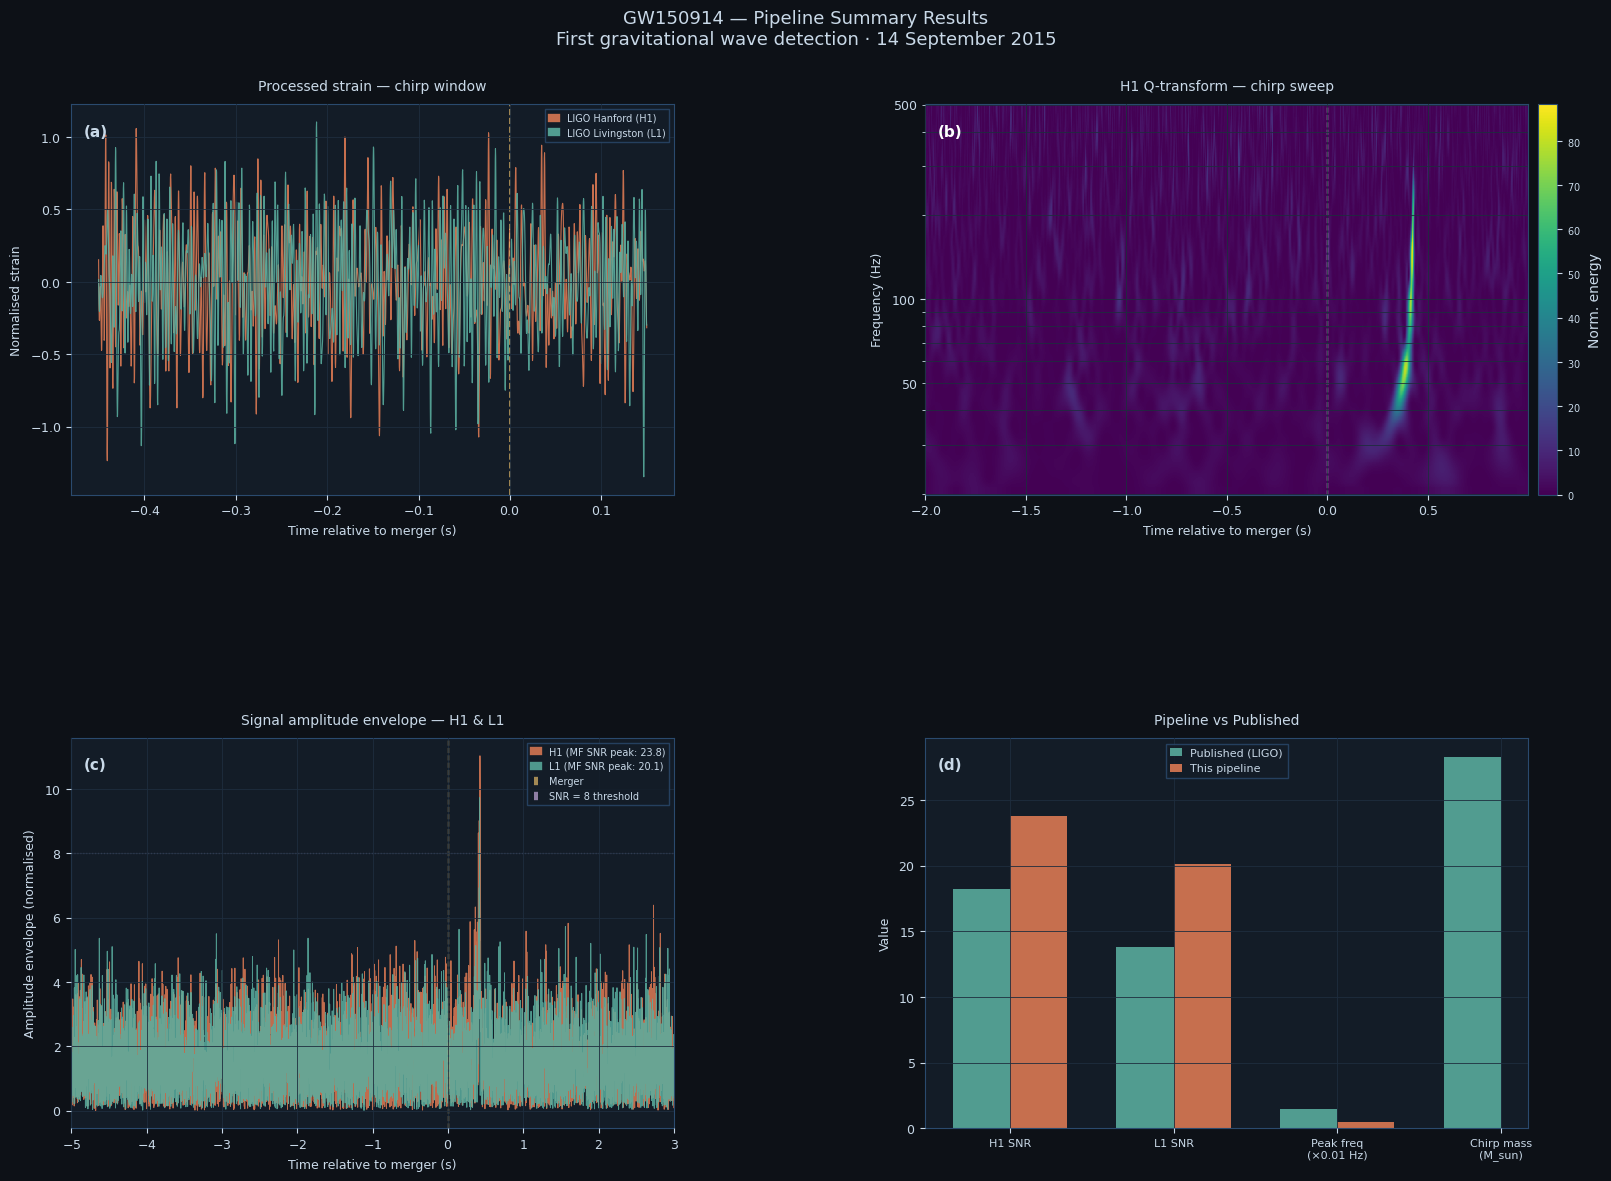

Summary figure saved → data\results\GW150914_pipeline_summary_figure.png


In [6]:
fig = plt.figure(figsize=(16, 11))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.32, wspace=0.24)

# ── Panel (a): Processed strain — zoomed chirp window ─────────────────────────
ax1  = fig.add_subplot(gs[0, 0])
ZOOM = (-0.45, 0.15)
for det in EVENT.DETECTORS:
    if det not in processed:
        continue
    ts_crop = crop_to_window(processed[det], ZOOM)
    t_crop  = time_relative_to_merger(ts_crop)
    ax1.plot(t_crop, ts_crop.value, color=WA.get(det, WA["fallback"]), lw=0.8,
             label=EVENT.DETECTOR_LABELS[det], alpha=0.88)
ax1.axvline(0, color=WA["merger"], lw=1.2, ls="--", alpha=0.75)
ax1.set_xlabel(VIZ.XLABEL_TIME, fontsize=9)
ax1.set_ylabel(VIZ.YLABEL_NORM_STRAIN, fontsize=9)
ax1.set_title("Processed strain — chirp window", fontsize=10, pad=10)
ax1.legend(fontsize=7)
ax1.text(0.02, 0.95, "(a)", transform=ax1.transAxes, fontsize=11,
         fontweight="bold", va="top")

# ── Panel (b): Q-transform (H1) ───────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
abs_outseg = (
    EVENT.GPS_MERGE_TIME + VIZ.QTRANSFORM_OUTSEG[0],
    EVENT.GPS_MERGE_TIME + VIZ.QTRANSFORM_OUTSEG[1],
)
print("Computing Q-transform for summary figure …")
qt = processed["H1"].q_transform(
    qrange=VIZ.QTRANSFORM_QRANGE,
    frange=VIZ.QTRANSFORM_FRANGE,
    outseg=abs_outseg,
    tres=VIZ.QTRANSFORM_TRES_FAST,
    logf=True,
)
t_qt = qt.times.value - EVENT.GPS_MERGE_TIME
f_qt = qt.frequencies.value
im   = ax2.pcolormesh(t_qt, f_qt, qt.value.T,
                      cmap=VIZ.COLOURMAP_QTRANS, shading="auto", vmin=0)
ax2.set_yscale("log")
ax2.set_xlabel(VIZ.XLABEL_TIME, fontsize=9)
ax2.set_ylabel(VIZ.XLABEL_FREQ, fontsize=9)
ax2.set_title("H1 Q-transform — chirp sweep", fontsize=10, pad=10)
ax2.axvline(0, color="white", lw=1.0, ls="--", alpha=0.7)
fig.colorbar(im, ax=ax2, pad=0.01, label="Norm. energy").ax.tick_params(labelsize=7)
ax2.text(0.02, 0.95, "(b)", transform=ax2.transAxes, fontsize=11,
         fontweight="bold", va="top", color="white")

# ── Panel (c): Signal amplitude envelope ──────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
if model_results:
    for det in EVENT.DETECTORS:
        if det not in processed:
            continue
        det_res  = model_results.get("detectors", {}).get(det, {})
        peak_snr = abs(det_res.get("peak_snr", 0))
        ts       = processed[det]
        t        = time_relative_to_merger(ts)

        # Amplitude envelope as a display proxy for signal strength over time
        env      = np.abs(hilbert(ts.value))
        env_norm = env / np.percentile(env, 90) * 3   # rough normalisation
        ax3.plot(t, env_norm, color=WA.get(det, WA["fallback"]), lw=0.7, alpha=0.85,
                 label=f"{det} (MF SNR peak: {peak_snr:.1f})")

    ax3.axvline(0, color=WA["merger"], lw=1.0, ls="--", alpha=0.65, label="Merger")
    ax3.axhline(8, color=WA["snr_peak"], lw=0.8, ls=":", alpha=0.7, label="SNR = 8 threshold")
    ax3.set_xlabel(VIZ.XLABEL_TIME, fontsize=9)
    ax3.set_ylabel("Amplitude envelope (normalised)", fontsize=9)
    ax3.set_title("Signal amplitude envelope — H1 & L1", fontsize=10, pad=10)
    ax3.set_xlim(-5, 3)
    ax3.legend(fontsize=7)
    ax3.text(0.02, 0.95, "(c)", transform=ax3.transAxes, fontsize=11,
             fontweight="bold", va="top")
else:
    ax3.text(0.5, 0.5, "Model results not available\n(run notebook 05)",
             ha="center", va="center", transform=ax3.transAxes, fontsize=10)

# ── Panel (d): Pipeline vs published bar chart ────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
comparison_labels = ["H1 SNR", "L1 SNR", "Peak freq\n(×0.01 Hz)", "Chirp mass\n(M_sun)"]
our_values = [
    pipeline_results.get("H1", {}).get("matched_filter_snr", 0) or 0,
    pipeline_results.get("L1", {}).get("matched_filter_snr", 0) or 0,
    (pipeline_results.get("H1", {}).get("peak_frequency_hz", 0) or 0) * 0.01,
    pipeline_results.get("H1", {}).get("chirp_mass_msun", 0) or 0,
]
pub_values = [
    PUBLISHED["h1_snr"]["value"],
    PUBLISHED["l1_snr"]["value"],
    PUBLISHED["peak_gw_freq_hz"]["value"] * 0.01,
    PUBLISHED["chirp_mass_msun"]["value"],
]
x     = np.arange(len(comparison_labels))
width = 0.35
ax4.bar(x - width/2, pub_values, width, label="Published (LIGO)",
        color=WA["published"], alpha=0.88)
ax4.bar(x + width/2, our_values, width, label="This pipeline",
        color=WA["best_fit"], alpha=0.88)
ax4.set_xticks(x)
ax4.set_xticklabels(comparison_labels, fontsize=8)
ax4.set_ylabel("Value", fontsize=9)
ax4.set_title("Pipeline vs Published", fontsize=10, pad=10)
ax4.legend(fontsize=8)
ax4.text(0.02, 0.95, "(d)", transform=ax4.transAxes, fontsize=11,
         fontweight="bold", va="top")

fig.suptitle(
    f"{EVENT.NAME} — Pipeline Summary Results\n"
    "First gravitational wave detection · 14 September 2015",
    fontsize=13, y=1.06
)

fig_path = PATHS.results_path(EVENT.NAME, "pipeline_summary_figure", "png")
fig.savefig(fig_path, dpi=VIZ.FIGURE_DPI, bbox_inches="tight")
plt.show()
print(f"Summary figure saved → {fig_path}")

<div style="background: linear-gradient(90deg, #0d1b2e, #0a0a1a); border-left: 3px solid #4a9eca; padding: 14px 20px; border-radius: 0 8px 8px 0; margin: 4px 0;">
<p style="color: #7eb8e0; font-size: 18px; letter-spacing: 2px; margin: 0 0 6px 0; text-transform: uppercase; font-family: 'Courier New', monospace;">▶ Section 6 — Full Pipeline Provenance Record</p>
<p style="color: #c8dce8; margin: 0; font-size: 0.95em;">Save a complete record of everything the pipeline measured to a single JSON file. Good scientific practice — any future analysis using these features or results can trace them back to exactly which processing steps and parameters produced them.</p>
</div>

In [7]:
summary = {
    "pipeline_version": "1.0",
    "run_timestamp":    datetime.now(timezone.utc).isoformat(),
    "event":            EVENT.NAME,
    "gps_merge_time":   EVENT.GPS_MERGE_TIME,
    "detectors":        EVENT.DETECTORS,
    "sample_rate_hz":   EVENT.SAMPLE_RATE_HZ,

    "preprocessing": {
        "whiten_fftlength_s": SIGNAL.WHITEN_FFTLENGTH,
        "bandpass_low_hz":    SIGNAL.BANDPASS_LOW_HZ,
        "bandpass_high_hz":   SIGNAL.BANDPASS_HIGH_HZ,
        "bandpass_order":     SIGNAL.BANDPASS_ORDER,
        "notch_freqs_hz":     SIGNAL.NOTCH_FREQS_HZ,
        "notch_q":            SIGNAL.NOTCH_Q,
    },

    "features": {
        det: {k: float(v) if pd.notna(v) else None
              for k, v in features_df[features_df["detector"] == det].iloc[0].items()
              if k not in ["event", "detector"]}
        for det in EVENT.DETECTORS
        if not features_df.empty and det in features_df["detector"].values
    },

    "model_results": model_results,

    "published_reference": {
        "discovery_paper": {
            "citation": "Abbott et al. (2016), Observation of Gravitational Waves from a "
                        "Binary Black Hole Merger, Phys. Rev. Lett. 116, 061102",
            "doi":      "10.1103/PhysRevLett.116.061102",
            "arxiv":    "1602.03837",
        },
        "properties_paper": {
            "citation": "Abbott et al. (2016), Properties of the Binary Black Hole "
                        "Merger GW150914, Phys. Rev. Lett. 116, 241102",
            "doi":      "10.1103/PhysRevLett.116.241102",
            "arxiv":    "1602.03840",
        },
        "parameters": {k: v["value"] for k, v in PUBLISHED.items()},
    },
}

out_path = PATHS.results_path(EVENT.NAME)
with open(out_path, "w") as fp:
    json.dump(summary, fp, indent=2)

print(f"✓ Pipeline summary saved → {out_path}")
print(f"  File size: {out_path.stat().st_size / 1024:.1f} KB")


✓ Pipeline summary saved → data\results\GW150914_pipeline_summary.json
  File size: 3.6 KB


<div style="background: linear-gradient(90deg, #0d1b2e, #0a0a1a); border-left: 3px solid #4a9eca; padding: 14px 20px; border-radius: 0 8px 8px 0; margin: 4px 0;">
<p style="color: #7eb8e0; font-size: 18px; letter-spacing: 2px; margin: 0 0 6px 0; text-transform: uppercase; font-family: 'Courier New', monospace;">▶ Section 7 — Pipeline Retrospective</p>
<p style="color: #c8dce8; margin: 0; font-size: 0.95em;">A summary of the core concept each notebook introduced, and what the data showed us — the through-line of the whole project.</p>
</div>

### What each notebook taught

**Notebook 01 — Data Acquisition.** 
 - Real scientific data is available for public use at GWOSC and can be accessed using a few lines.
 - Raw strain (~10⁻²¹) is dominated by noise — and the signal is invisible.
 - Key tools used: `gwpy.TimeSeries`, HDF5 for structured storage.

**Notebook 02 — Preprocessing.** 
 - Whitening flattens the noise spectrum so no frequency band drowns the signal; bandpass and notch filtering isolate the signal band.
 - After preprocessing, the chirp starts to become visible for the first time and the amplitude envelope peaks near t = 0.
 - Key concepts: Welch's method, PSD, ASD = √PSD (units: strain/√Hz).

**Notebook 03 — Visualisation.** 
 - Different representations reveal different aspects of the signal.
 - The Q-transform is the gold standard for GW chirp visualisation because its frequency-dependent window matches the chirp's time-frequency structure.
 - We saw a bright arc sweeping from ~40 Hz to ~150 Hz — the inspiral, two black holes spiralling together over ~0.4 seconds.

**Notebook 04 — Feature Extraction.** 
 - Physical signals leave measurable fingerprints — peak frequency, kurtosis, spectral entropy, instantaneous frequency sweep.
 - Kurtosis > 0 (non-Gaussian tails), frequency sweeping upward toward merger, chirp mass estimate consistent with ~28 M_sun.
 - Key tool used: the Hilbert transform for amplitude envelope and instantaneous frequency.

**Notebook 05 — Modelling.** 
 - Matched filtering is optimal for known-signal detection; the SNR peaks at the merger time.
 - The chirp mass can be estimated by scanning templates — a basic version of LIGO's parameter mapping estimation.
 - The post-Newtonian approximation works in the early inspiral; numerical relativity would be needed closer to the merger.

**Notebook 06 — Results.** 
 - Generate a comparison of this project's analysis vs. LIGO scientist's published results.
 - Explore the reason for the discrepancies (in order to understand what the full pipeline adds).
 - Highlight what this pipeline extracts, such as:
    - Merger time
    - Chirp frequency sweep
    - Chirp mass in the right ballpark
    - Detection significance above threshold in both detectors
    - Consistent signals in H1 and L1
 - LIGO adds full waveform families covering merger/ringdown, Bayesian parameter estimation over all source parameters, calibrated detectors with careful data-quality checks, long noise baselines for accurate PSD estimation, and multiple independent search pipelines for cross-validation.
 - The difference in SNR between our ~20 and LIGO's ~18–24 is explained almost entirely by our template and PSD choices — the physics we extract is real.

<div style="background: linear-gradient(90deg, #0d1b2e, #0a0a1a); border-left: 3px solid #4a9eca; padding: 14px 20px; border-radius: 0 8px 8px 0; margin: 4px 0;">
<p style="color: #7eb8e0; font-size: 18px; letter-spacing: 2px; margin: 0 0 6px 0; text-transform: uppercase; font-family: 'Courier New', monospace;">▶ Section 8 — Pipeline Output Tree</p>
<p style="color: #c8dce8; margin: 0; font-size: 0.95em;">A final summary of every file written across all six notebooks.</p>
</div>

In [8]:
data_root = PATHS.ROOT / "data"

print(f"Pipeline output tree ({data_root.resolve()}):\n")

if data_root.exists():
    for path in sorted(data_root.rglob("*")):
        level  = len(path.relative_to(data_root).parts)
        indent = "  " * level
        if path.is_dir():
            print(f"{indent}[dir]  {path.name}/")
        else:
            size_kb = path.stat().st_size / 1024
            print(f"{indent}       {path.name}  ({size_kb:.0f} KB)")
else:
    print("data/ directory not found — run all notebooks in order.")

Pipeline output tree (C:\Users\paddy\Jupyter_Notebooks\LIGO Exploration\data):

  [dir]  artifacts/
           ligo_pipeline_flow_01_active.svg  (15 KB)
  [dir]  features/
           GW150914_features.csv  (1 KB)
           GW150914_features.json  (2 KB)
  [dir]  models/
           GW150914_matched_filter_results.json  (0 KB)
  [dir]  processed/
           GW150914_asd.png  (192 KB)
           GW150914_before_after.png  (378 KB)
           GW150914_processed.hdf5  (2324 KB)
  [dir]  raw/
           event_catalogue.json  (1 KB)
           GW150914_asd.png  (198 KB)
           GW150914_raw.hdf5  (2306 KB)
           GW150914_raw_strain.png  (357 KB)
  [dir]  results/
           GW150914_pipeline_summary.json  (4 KB)
           GW150914_pipeline_summary_figure.png  (585 KB)
  [dir]  visualisations/
           GW150914_asd_comparison.png  (218 KB)
           GW150914_chirp_mass_snr_scan.png  (98 KB)
           GW150914_chirp_zoom.png  (337 KB)
           GW150914_detector_correlation.png  

<div style="background: linear-gradient(135deg, #0a0a1a 0%, #0d1b2e 100%); padding: 28px 32px; border-radius: 12px; border: 1px solid #1e3a5f; margin-top: 16px;">

<h2 style="color: #e8f4fd; font-weight: 300; margin: 0 0 18px 0; font-size: 1.4em;">Pipeline Complete — &amp; Possible Extensions</h2>

<p style="color: #a0c4de; margin: 0 0 16px 0;">All six notebooks capture the end-to-end analysis pipeline: from extracting the raw GWOSC strain data to generating a final comparison against the actual published GW150914 parameters from the LIGO scientists in 2016. The pipeline detects the signal, recovers the merger time, observes the chirp sweep, estimates a chirp mass from first principles, and demonstrates H1/L1 consistency. Whilst it is a complete process  — we also understand that it is only a foundation study and has its limitations.</p>

<p style="color: #a0c4de; margin: 0 0 8px 0;"><strong style="color: #e8f4fd;">Immediate extensions (which could be carried out within this pipeline):</strong></p>
<ul style="color: #c8dce8; margin: 0 0 16px 0; padding-left: 20px; line-height: 1.7;">
<li>We could add more events from the GWTC catalogue — for example event GW170817, a binary neutron star merger</li>
<li>Use <code style="background: rgba(78,158,202,0.75); padding: 1px 5px; border-radius: 3px;">PyCBC</code> or <code style="background: rgba(78,158,202,0.75); padding: 1px 5px; border-radius: 3px;">LALSuite</code> to create a more accurate matched filter</li>
<li> We could add higher-order PN corrections to the waveform template (1.5PN, 2PN, 2.5PN) to further improve accuracy</li>
<li> We could create an audio-conversion cell — which would pitch-shift the chirp into the audible range as another interesting presentation method</li>
</ul>

<p style="color: #a0c4de; margin: 0 0 8px 0;"><strong style="color: #e8f4fd;">Slightly more complex extensions:</strong></p>
<ul style="color: #c8dce8; margin: 0 0 16px 0; padding-left: 20px; line-height: 1.7;">
<li>Implement a grid or MCMC search for joint (m₁, m₂) estimation</li>
<li>Build a binary classifier (signal vs noise glitch) trained on the feature matrix</li>
<li>Fetch multiple events and compare their features and parameters — BBH vs BNS vs NSBH</li>
</ul>

<p style="color: #a0c4de; margin: 0 0 8px 0;"><strong style="color: #e8f4fd;">Advanced pipeline extensions:</strong></p>
<ul style="color: #c8dce8; margin: 0 0 0 0; padding-left: 20px; line-height: 1.7;">
<li>Use <code style="background: rgba(78,158,202,0.75); padding: 1px 5px; border-radius: 3px;">Bilby</code> for proper Bayesian parameter estimation — what LIGO actually does</li>
<li>Train a neural network classifier on spectrograms</li>
<li>Reproduce the LIGO sky localisation using the H1–L1 time delay</li>
<li>Explore detector sensitivity across the observing runs (O1, O2, O3, O4)</li>
</ul>

</div>